In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv(r"C:\Users\Roman Shypka\OneDrive\Робочий стіл\data.csv")

In [20]:
data

,data_size,train_time
0,10000,8
1,20000,20
2,40000,55
3,80000,150
4,160000,420


In [21]:
data = data.rename(columns={"n":"data_size","t":"train_time"})

In [22]:
data

,data_size,train_time
0,10000,8
1,20000,20
2,40000,55
3,80000,150
4,160000,420


In [24]:
x_nodes = data['data_size'].values
y_nodes = data['train_time'].values

In [25]:
# Функція для розділених різниць 
def get_divided_diff(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    for j in range(1, n):
        for i in range(n - j):
            coef[i,j] = (coef[i+1,j-1] - coef[i,j-1]) / (x[i+j] - x[i])
    return coef[0, :]

In [26]:
coeffs = get_divided_diff(x_nodes, y_nodes)

In [27]:
# Функція інтерполяції Ньютона
def newton_interpolation(coeffs, x_nodes, x):
    res = coeffs[0]
    product = 1.0
    for i in range(1, len(x_nodes)):
        product *= (x - x_nodes[i-1])
        res += coeffs[i] * product
    return res


In [45]:
prediction = newton_interpolation(coeffs, x_nodes, 120000)
print(f"Прогнозований час: {prediction:.2f} сек.")

Прогнозований час: 265.19 сек.


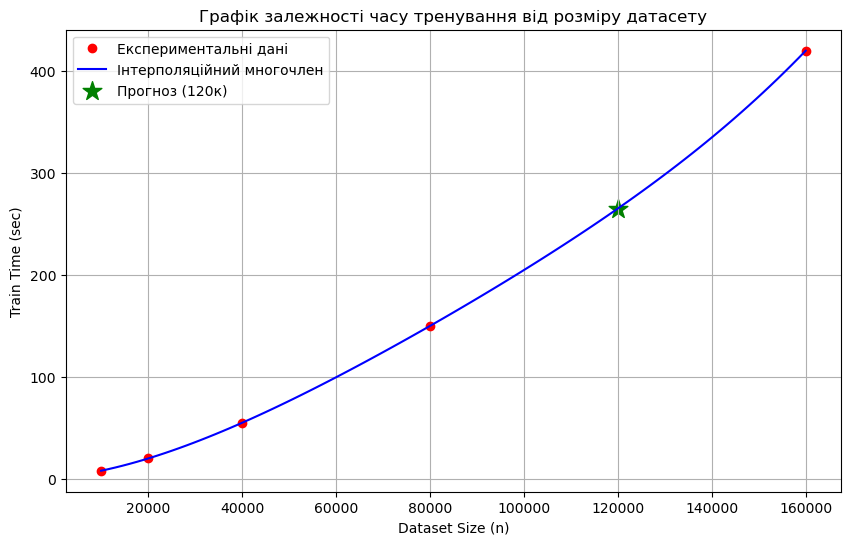

In [48]:
# Створюємо масив значень для плавної лінії графіка
x_fine = np.linspace(x_nodes.min(), x_nodes.max(), 100)
y_fine = [newton_interpolation(coeffs, x_nodes, x) for x in x_fine]

plt.figure(figsize=(10, 6))
plt.plot(x_nodes, y_nodes, 'ro', label='Експериментальні дані') # Точки з CSV 
plt.plot(x_fine, y_fine, 'b-', label='Інтерполяційний многочлен') # Крива 
plt.scatter([120000], [prediction], color='green', marker='*', s=200, label='Прогноз (120к)')

plt.title('Графік залежності часу тренування від розміру датасету')
plt.xlabel('Dataset Size (n)')
plt.ylabel('Train Time (sec)')
plt.legend()
plt.grid(True)

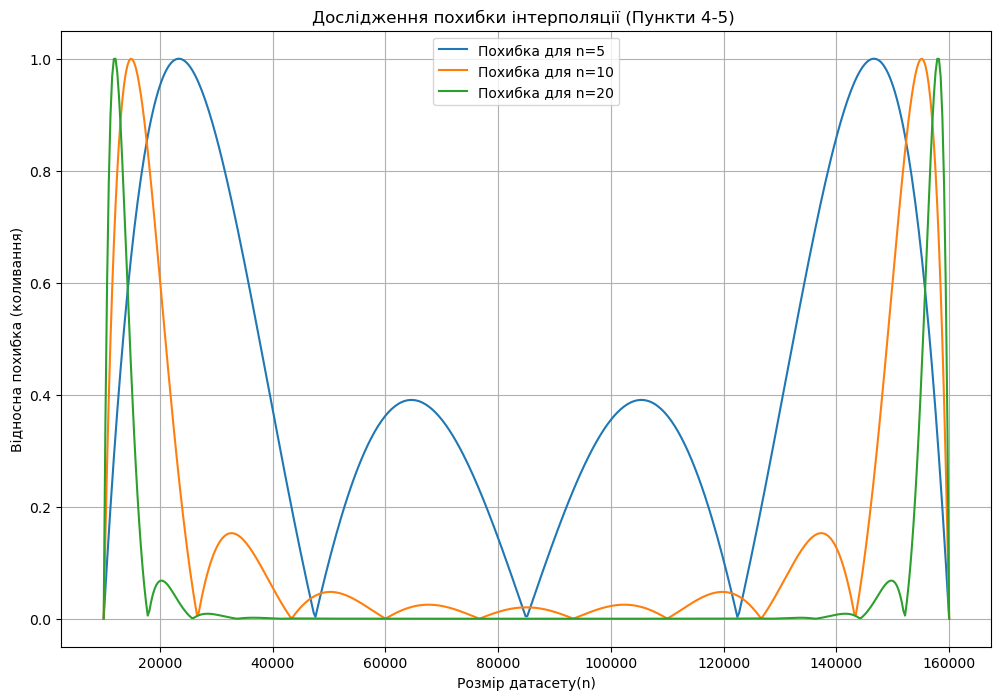

In [41]:
# Дослідження для n=5, 10, 20 
n_values = [5, 10, 20]
plt.figure(figsize=(12, 8))

for n_count in n_values:
    # 1. Створюємо n_count вузлів на інтервалі 
    x_nodes_new = np.linspace(x_nodes.min(), x_nodes.max(), n_count)
    
    # 2. Оскільки ми досліджуємо похибку, обчислюємо значення полінома [cite: 159, 259]
    y_nodes_new = [newton_interpolation(coeffs, x_nodes, xi) for xi in x_nodes_new]
    
    # 3. Будуємо графік похибки (функція w_n(x)) [cite: 159, 160]
    x_test = np.linspace(x_nodes.min(), x_nodes.max(), 500)
    # Теоретична похибка пропорційна добутку (x-x0)(x-x1)... [cite: 67, 159]
    y_err = [abs(np.prod([xi - xj for xj in x_nodes_new])) for xi in x_test]
    
    # Нормалізуємо для наочності графіка
    y_err = y_err / np.max(y_err) if np.max(y_err) != 0 else y_err
    
    plt.plot(x_test, y_err, label=f'Похибка для n={n_count}')

plt.title('Дослідження похибки інтерполяції (Пункти 4-5) ')
plt.xlabel('Розмір датасету(n)')
plt.ylabel('Відносна похибка (коливання)')
plt.legend()
plt.grid(True)
plt.show()